# Object Detection with MATA

This notebook demonstrates how MATA result objects display automatically
in Jupyter notebooks using the rich HTML display protocol.

**Model used**: `facebook/detr-resnet-50` (requires HuggingFace Transformers)

**Prerequisites**: `pip install datamata[notebook]`

In [12]:
# Uncomment to install if needed:
# !pip install datamata[notebook]
# !pip install timm (facebook/detr-resnet-50 need this)
# Follow README.md for installation instructions.

In [25]:
import mata
from pathlib import Path

print(f"MATA version: {mata.__version__}")

IMAGE_1 = "../../examples/images/000000039769.jpg"
IMAGE_2 = "../../examples/images/000000015338.jpg"

for label, p in [("image 1", IMAGE_1), ("image 2", IMAGE_2)]:
    status = "✅ FOUND" if Path(p).exists() else "❌ NOT FOUND"
    print(f"  {label:10s}: {status}")

MATA version: 1.9.5
  image 1   : ✅ FOUND
  image 2   : ✅ FOUND


In [26]:
import os

# Create a runs folder for saving outputs
runs_dir = Path("../..") / "runs" / "detection"
runs_dir.mkdir(parents=True, exist_ok=True)

In [27]:
# Load a detector once for repeated use
detector = mata.load("detect", "facebook/detr-resnet-50")

[INFO] Loading detect model from huggingface: facebook/detr-resnet-50
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceDetectAdapter with device=cuda, threshold=0.3
[INFO] Loading HuggingFace model: facebook/detr-resnet-50
[INFO] Detected architecture: detr
[INFO] Model loaded successfully on cuda


Label,Score,BBox
remote,0.998,"(40, 71, 176, 118)"
remote,0.996,"(333, 73, 368, 188)"
couch,0.995,"(-0, 1, 640, 474)"
cat,0.999,"(13, 52, 314, 471)"
cat,0.999,"(345, 24, 640, 369)"

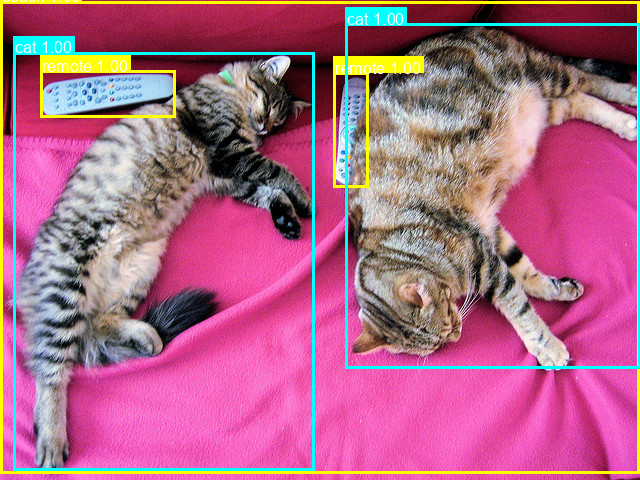

In [28]:
# Run inference on an image
result = detector.predict(IMAGE_1)

# Auto-display: just evaluate the result object in a cell
result

Label,Score,BBox
remote,0.998,"(40, 71, 176, 118)"
remote,0.996,"(333, 73, 368, 188)"
couch,0.995,"(-0, 1, 640, 474)"
cat,0.999,"(13, 52, 314, 471)"
cat,0.999,"(345, 24, 640, 369)"

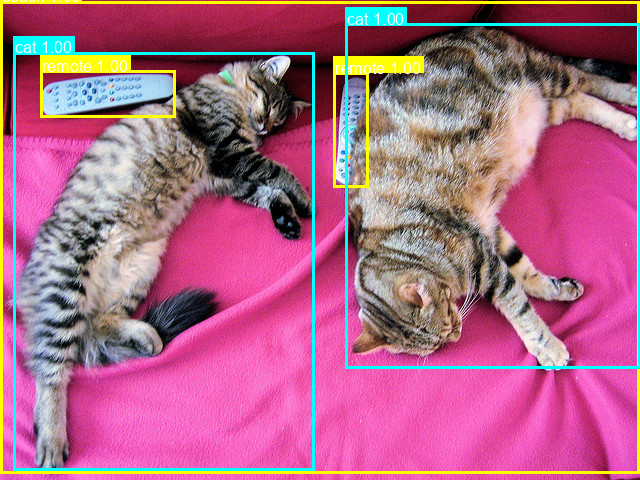

Saved to: ..\..\runs\detection\detection_detr_resnet50.png


In [29]:
# Display result with image overlay and save to runs folder
output_path = runs_dir / "detection_detr_resnet50.png"
mata.show(result, image=IMAGE_1, save=str(output_path))
print(f"Saved to: {output_path}")

Instances above 0.7 confidence: 5


Label,Score,BBox
remote,0.998,"(40, 71, 176, 118)"
remote,0.996,"(333, 73, 368, 188)"
couch,0.995,"(-0, 1, 640, 474)"
cat,0.999,"(13, 52, 314, 471)"
cat,0.999,"(345, 24, 640, 369)"

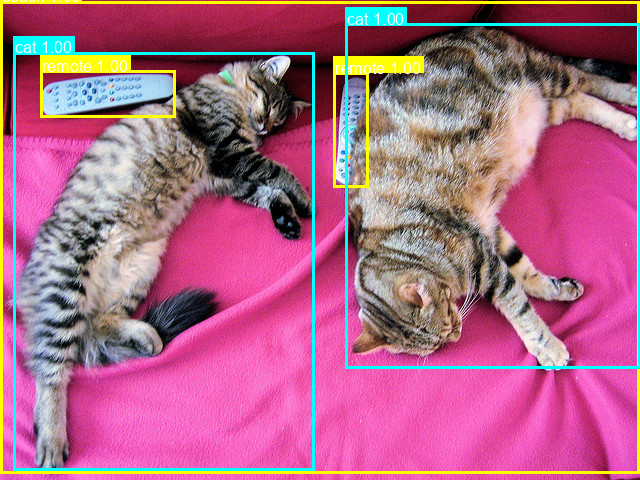

In [30]:
# Filter by confidence and display again
high_conf = result.filter_by_score(0.7)
print(f"Instances above 0.7 confidence: {len(high_conf.instances)}")
high_conf

## Change the model and run inference again

In [31]:
# Load a different detector (torchvision's fasterrcnn_resnet50_fpn_v2) and run inference again
detector = mata.load("detect", "torchvision/fasterrcnn_resnet50_fpn_v2")

[INFO] Loading detect model from torchvision: torchvision/fasterrcnn_resnet50_fpn_v2
[INFO] Loading torchvision detection model: torchvision/fasterrcnn_resnet50_fpn_v2
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized TorchvisionDetectAdapter with device=cuda, threshold=0.3
[INFO] Loading torchvision model: fasterrcnn_resnet50_fpn_v2
[INFO] Loaded with new API (weights='DEFAULT')
[INFO] Model loaded successfully on cuda


Label,Score,BBox
cat,0.999,"(339, 18, 640, 364)"
cat,0.999,"(16, 50, 324, 466)"
remote,0.976,"(37, 74, 176, 120)"
couch,0.869,"(6, 0, 640, 468)"
remote,0.727,"(333, 77, 370, 187)"
couch,0.321,"(0, 5, 636, 143)"

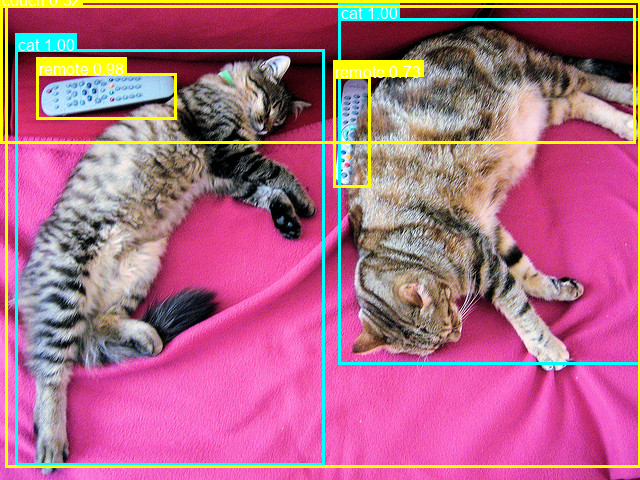

In [32]:
# Run inference on an image
result = detector.predict(IMAGE_1)

# Auto-display: just evaluate the result object in a cell
result

Label,Score,BBox
cat,0.999,"(339, 18, 640, 364)"
cat,0.999,"(16, 50, 324, 466)"
remote,0.976,"(37, 74, 176, 120)"
couch,0.869,"(6, 0, 640, 468)"
remote,0.727,"(333, 77, 370, 187)"
couch,0.321,"(0, 5, 636, 143)"

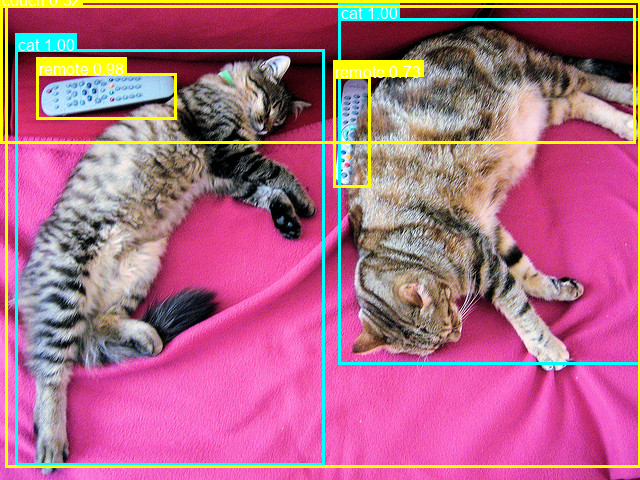

Saved to: ..\..\runs\detection\detection_fasterrcnn_resnet50.png


In [33]:
# Display result with image overlay and save to runs folder
output_path = runs_dir / "detection_fasterrcnn_resnet50.png"
mata.show(result, image=IMAGE_1, save=str(output_path))
print(f"Saved to: {output_path}")

Instances above 0.7 confidence: 5


Label,Score,BBox
cat,0.999,"(339, 18, 640, 364)"
cat,0.999,"(16, 50, 324, 466)"
remote,0.976,"(37, 74, 176, 120)"
couch,0.869,"(6, 0, 640, 468)"
remote,0.727,"(333, 77, 370, 187)"

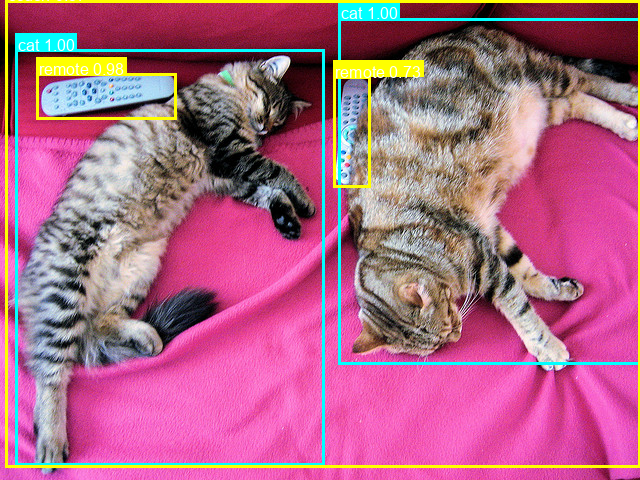

In [35]:
# Filter by confidence and display again
high_conf = result.filter_by_score(0.7)
print(f"Instances above 0.7 confidence: {len(high_conf.instances)}")
high_conf

## Notes

- `result` auto-renders as a rich HTML table in Jupyter cells
- `mata.show(result, image=...)` adds a visual image overlay
- `result.filter_by_score(threshold)` returns a new result with only high-confidence detections
- `result.to_json()` exports the full result as JSON